
# NBA Shot Data — 2024–25 Season (Full, Schema‑Adaptive)

This notebook normalizes the 2024–25 shot schema (e.g., `xLegacy`, `yLegacy`, `shotDistance`, `shotResult`, `SHOT_CLOCK_APPROX`, `teamTricode`, `playerName`, `gameId`) to a consistent set of fields and produces the following visuals:

- Overview metrics
- Shot selection (2 vs 3), distance distribution
- Court shot charts (positions + make vs miss)
- Player **FG%** leaders (min 200 attempts)
- **Hexbin by location colored with `eFG%`**
- **FG% heatmap** by *(distance × shot clock)*
- Team shot profiles *(3PA rate vs FG%)*
- **Team 3PA rate vs Points per Game** *(FG points only)*
- **Top 10 points‑per‑game players** *(FG points only)*
- **Player eFG% (x) vs Attempts (y), labeled, min 1000 attempts**
- **Player "Bad Shot" % (x) vs Attempts (y), labeled, min 800 attempts)**

> **Notes**
> - Uses only `matplotlib` (no seaborn), single‑figure charts.
> - PPG here is **field‑goal points only** (no FTs in this file).
> - The notebook is defensive: if a column is missing, the affected plot is skipped with a message.


## 0) Load & Normalize Schema

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Point this to your 2024–25 CSV (adjust if needed)
FILE_PATH = "enriched_data/nbastatsv3_2024_enriched_shots.csv"

shots_raw = pd.read_csv(FILE_PATH)
print(f"Loaded {len(shots_raw):,} rows, {shots_raw.shape[1]} columns")
print("Columns:", list(shots_raw.columns))

shots = shots_raw.copy()

# === Normalize from 2024–25 schema to standard fields ===
# Player name
if 'name' not in shots.columns and 'playerName' in shots.columns:
    shots['name'] = shots['playerName']

# Team
if 'team_name' not in shots.columns:
    if 'teamTricode' in shots.columns:
        shots['team_name'] = shots['teamTricode']
    elif 'teamName' in shots.columns:
        shots['team_name'] = shots['teamName']

# Game id
if 'espn_game_id' not in shots.columns and 'gameId' in shots.columns:
    shots['espn_game_id'] = shots['gameId']

# Coordinates
if 'x' not in shots.columns and 'xLegacy' in shots.columns:
    shots['x'] = shots['xLegacy']
if 'y' not in shots.columns and 'yLegacy' in shots.columns:
    shots['y'] = shots['yLegacy']

# Distance
if 'shot_distance' not in shots.columns and 'shotDistance' in shots.columns:
    shots['shot_distance'] = shots['shotDistance']

# Shot clock
if 'shot_clock' not in shots.columns:
    if 'SHOT_CLOCK_APPROX' in shots.columns:
        shots['shot_clock'] = pd.to_numeric(shots['SHOT_CLOCK_APPROX'], errors='coerce')
    elif 'shot_clock' in shots.columns:
        pass

# Made/miss
if 'shot_made_flag' not in shots.columns:
    if 'shotResult' in shots.columns:
        shots['shot_made_flag'] = (shots['shotResult'].astype(str).str.lower()=='made').astype(int)
    else:
        # If not available, leave NaN; downstream cells will skip gracefully.
        shots['shot_made_flag'] = np.nan

# Ensure numeric types
for col in ['x','y','shot_distance','shot_clock','shotValue','contest_score']:
    if col in shots.columns:
        shots[col] = pd.to_numeric(shots[col], errors='coerce')

display_cols = ['name','team_name','espn_game_id','x','y','shot_distance','shot_clock','shotValue','shot_made_flag','contest_score','contest_label']
shots[ [c for c in display_cols if c in shots.columns] ].head(8)


Loaded 219,528 rows, 30 columns
Columns: ['actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId', 'gameId', 'ABS_TIME', 'SHOT_CLOCK_APPROX', 'SHOT_CLOCK_SOURCE', 'contest_score', 'contest_label', 'contest_reasons']


,name,team_name,espn_game_id,x,y,shot_distance,shot_clock,shotValue,shot_made_flag,contest_score,contest_label
0,Risacher,ATL,22400001,-168,205,27,17.0,3,0,-2,likely_open
1,Risacher,ATL,22400001,10,13,2,0.0,2,1,2,likely_contested
2,Risacher,ATL,22400001,53,111,12,14.0,2,0,3,likely_contested
3,Risacher,ATL,22400001,-10,17,2,1.0,2,0,4,likely_contested
4,Risacher,ATL,22400001,-10,1,1,0.0,2,0,4,likely_contested
5,Risacher,ATL,22400001,0,0,0,2.0,2,0,4,likely_contested
6,Risacher,ATL,22400001,-21,15,3,0.0,2,1,2,likely_contested
7,Risacher,ATL,22400001,163,185,25,11.0,3,0,-1,likely_open


## 1) Quick Schema & Hygiene

In [3]:

print(shots.dtypes)
missing = shots.isna().mean().sort_values(ascending=False)
print("\nMissing ratio by column (top 12):")
print(missing.head(12))

expected = ['name','team_name','espn_game_id','x','y','shot_made_flag','shotValue','shot_distance','shot_clock','contest_score','contest_label']
missing_cols = [c for c in expected if c not in shots.columns]
print("\nMissing expected (plots may skip):", missing_cols)


actionNumber           int64
clock                 object
period                 int64
teamId                 int64
teamTricode           object
personId               int64
playerName            object
playerNameI           object
xLegacy                int64
yLegacy                int64
shotDistance           int64
shotResult            object
isFieldGoal            int64
scoreHome            float64
scoreAway            float64
pointsTotal            int64
location              object
description           object
actionType            object
subType               object
videoAvailable         int64
shotValue              int64
actionId               int64
gameId                 int64
ABS_TIME               int64
SHOT_CLOCK_APPROX    float64
SHOT_CLOCK_SOURCE     object
contest_score          int64
contest_label         object
contest_reasons       object
name                  object
team_name             object
espn_game_id           int64
x                      int64
y             

## 2) Overview KPIs

In [4]:

total_shots = len(shots)
fg_pct = shots['shot_made_flag'].mean() if 'shot_made_flag' in shots else np.nan
seasons = sorted(shots['season'].dropna().unique()) if 'season' in shots else []

print(f"Total shots: {total_shots:,}")
print(f"Overall FG%: {fg_pct:.2%}" if not np.isnan(fg_pct) else "Overall FG%: N/A")
print("Seasons present:", seasons)


Total shots: 219,528
Overall FG%: 46.72%
Seasons present: []


## 3) Shot Selection — 2PA vs 3PA

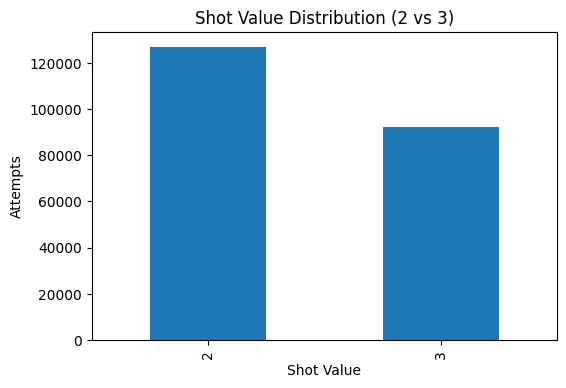

In [5]:

if 'shotValue' in shots.columns:
    fig = plt.figure(figsize=(6,4))
    shots['shotValue'].value_counts().sort_index().plot(kind='bar')
    plt.title("Shot Value Distribution (2 vs 3)")
    plt.xlabel("Shot Value"); plt.ylabel("Attempts"); plt.show()
else:
    print("No 'shotValue' column.")


## 4) Shot Distance Distribution

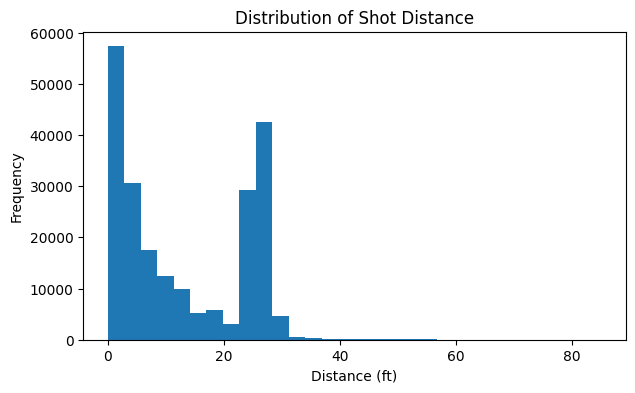

In [6]:

if 'shot_distance' in shots.columns:
    fig = plt.figure(figsize=(7,4))
    plt.hist(shots['shot_distance'].dropna(), bins=30)
    plt.title("Distribution of Shot Distance")
    plt.xlabel("Distance (ft)"); plt.ylabel("Frequency"); plt.show()
else:
    print("No 'shot_distance' column (expected from 'shotDistance').")


## 5) Court Shot Charts

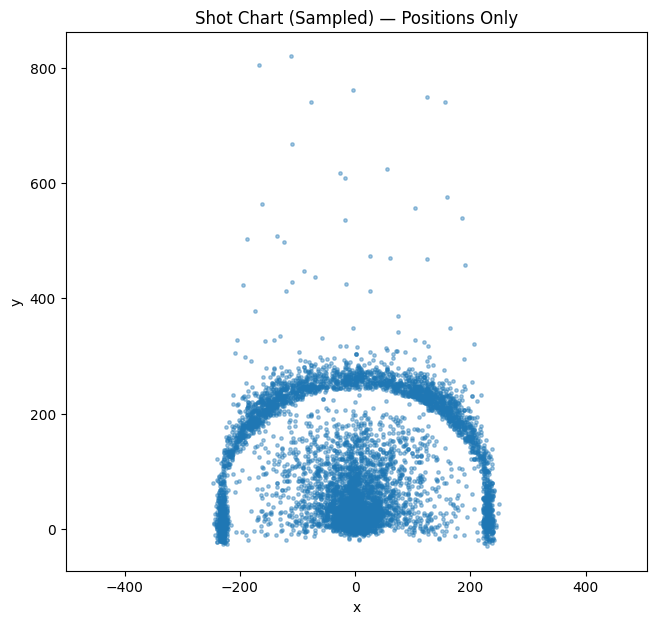

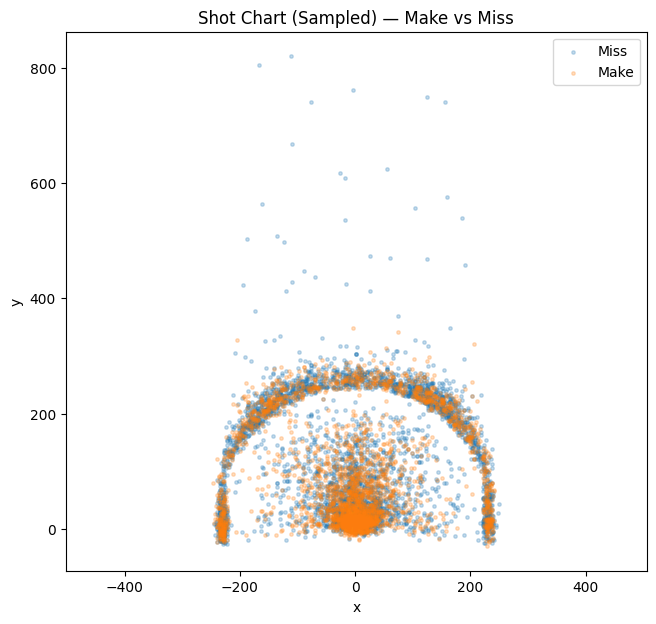

In [7]:

need = {'x','y','shot_made_flag'}
if need.issubset(shots.columns):
    sample_n = min(7500, len(shots))
    sampled = shots.sample(sample_n, random_state=42)[['x','y','shot_made_flag']].dropna()

    fig = plt.figure(figsize=(7.5,7))
    plt.scatter(sampled['x'], sampled['y'], s=6, alpha=0.4)
    plt.title("Shot Chart (Sampled) — Positions Only")
    plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal'); plt.show()

    made = sampled[sampled['shot_made_flag']==1]
    miss = sampled[sampled['shot_made_flag']==0]
    fig = plt.figure(figsize=(7.5,7))
    plt.scatter(miss['x'], miss['y'], s=6, alpha=0.25, label="Miss")
    plt.scatter(made['x'], made['y'], s=6, alpha=0.25, label="Make")
    plt.title("Shot Chart (Sampled) — Make vs Miss")
    plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal'); plt.legend(); plt.show()
else:
    print("Need columns x, y, shot_made_flag; skipping chart.")


## 6) Player FG% Leaders (min 200 attempts)

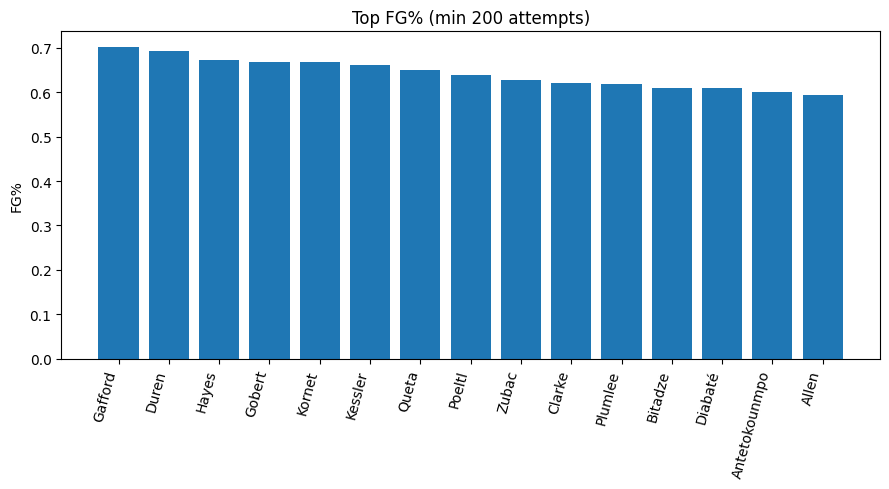

In [8]:

if {'name','shot_made_flag'}.issubset(shots.columns):
    stats = (shots.groupby('name')
                   .agg(attempts=('shot_made_flag','size'),
                        fg_pct=('shot_made_flag','mean'))
                   .reset_index())
    leaders = stats.query('attempts >= 200').sort_values('fg_pct', ascending=False).head(15)
    fig = plt.figure(figsize=(9,5))
    plt.bar(leaders['name'], leaders['fg_pct'])
    plt.title("Top FG% (min 200 attempts)")
    plt.ylabel("FG%"); plt.xticks(rotation=75, ha='right'); plt.tight_layout(); plt.show()
else:
    print("Missing 'name' or 'shot_made_flag'.")


## 7) Hexbin — eFG% by Location (min 20 attempts per hex)

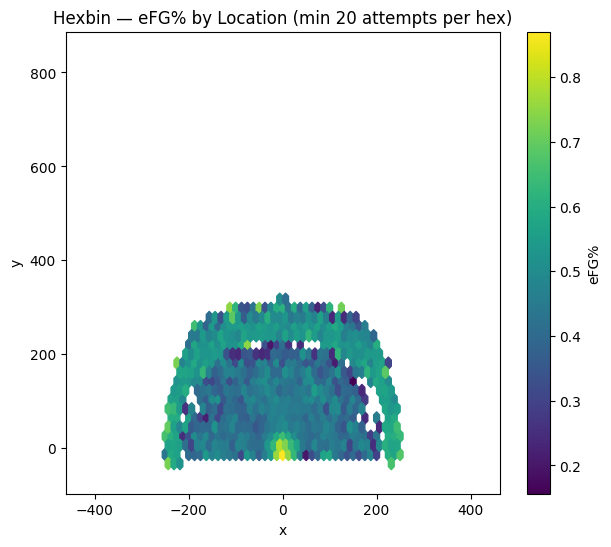

In [9]:

need = {'x','y','shot_made_flag','shotValue'}
if need.issubset(shots.columns):
    sh = shots.copy()
    sh['efg_contrib'] = sh['shot_made_flag'] * (1 + 0.5*(sh['shotValue']==3))
    fig = plt.figure(figsize=(7,6))
    hb = plt.hexbin(sh['x'].values, sh['y'].values,
                    C=sh['efg_contrib'].values.astype(float),
                    gridsize=40, reduce_C_function=np.mean, mincnt=20)
    plt.title("Hexbin — eFG% by Location (min 20 attempts per hex)")
    plt.xlabel("x"); plt.ylabel("y"); cb = plt.colorbar(hb); cb.set_label("eFG%"); plt.axis('equal'); plt.show()
else:
    print("Need x, y, shot_made_flag, shotValue.")


## 8) FG% Heatmap — Distance × Shot Clock

/var/folders/02/8qskm_yj6gx6xyj73fgxk36h0000gp/T/ipykernel_11718/1974945682.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = shots.pivot_table(values='shot_made_flag', index=i, columns=j, aggfunc='mean')


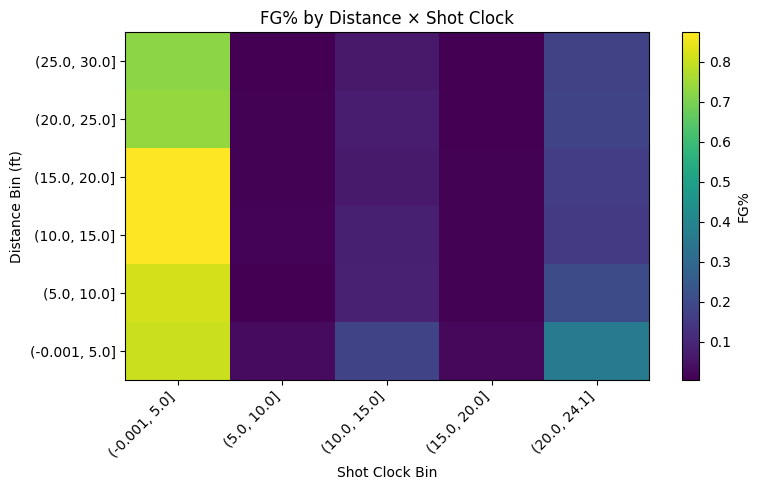

In [10]:

if {'shot_made_flag','shot_distance','shot_clock'}.issubset(shots.columns):
    dist_bins = [0,5,10,15,20,25,30]
    clock_bins = [0,5,10,15,20,24.1]
    i = pd.cut(shots['shot_distance'], bins=dist_bins, include_lowest=True)
    j = pd.cut(shots['shot_clock'], bins=clock_bins, include_lowest=True)
    pivot = shots.pivot_table(values='shot_made_flag', index=i, columns=j, aggfunc='mean')

    fig = plt.figure(figsize=(8,5))
    plt.imshow(pivot.values, aspect='auto', origin='lower')
    plt.title("FG% by Distance × Shot Clock")
    plt.xlabel("Shot Clock Bin"); plt.ylabel("Distance Bin (ft)")
    plt.colorbar(label="FG%")
    import numpy as np
    plt.xticks(np.arange(len(pivot.columns)), [str(c) for c in pivot.columns], rotation=45, ha='right')
    plt.yticks(np.arange(len(pivot.index)), [str(r) for r in pivot.index])
    plt.tight_layout(); plt.show()
else:
    print("Need 'shot_made_flag','shot_distance','shot_clock'.")


## 9) Team Shot Profiles — 3PA Rate vs FG% (bubble = avg distance)

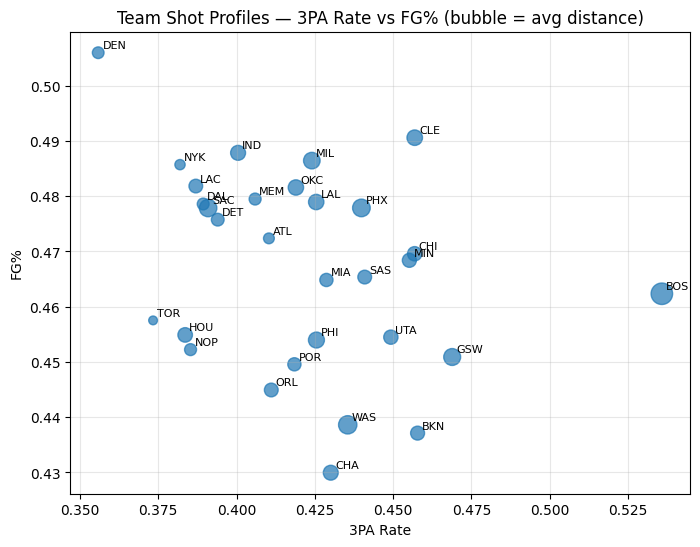

In [11]:

need = {'team_name','shotValue','shot_made_flag','shot_distance'}
if need.issubset(shots.columns):
    team = (shots.groupby('team_name')
                  .agg(avg_dist=('shot_distance','mean'),
                       three_rate=('shotValue', lambda x: np.mean(x==3)),
                       fg_pct=('shot_made_flag','mean'))
                  .reset_index())
    fig = plt.figure(figsize=(8,6))
    sizes = 200 * (team['avg_dist'] - team['avg_dist'].min()) / (team['avg_dist'].max() - team['avg_dist'].min() + 1e-9) + 40
    plt.scatter(team['three_rate'], team['fg_pct'], s=sizes, alpha=0.7)
    for _, r in team.iterrows():
        plt.annotate(r['team_name'], (r['three_rate'], r['fg_pct']), xytext=(3,3), textcoords='offset points', fontsize=8)
    plt.title("Team Shot Profiles — 3PA Rate vs FG% (bubble = avg distance)")
    plt.xlabel("3PA Rate"); plt.ylabel("FG%"); plt.grid(True, alpha=0.3); plt.show()
else:
    print("Missing columns for team profile.")


## 10) Helper — Compute Field‑Goal Points

In [12]:

if {'shot_made_flag','shotValue'}.issubset(shots.columns):
    shots['fg_points'] = shots['shot_made_flag'] * shots['shotValue']
else:
    print("Missing 'shot_made_flag' or 'shotValue'.")


## 11) Team 3PA Rate vs Points per Game (FG‑only)

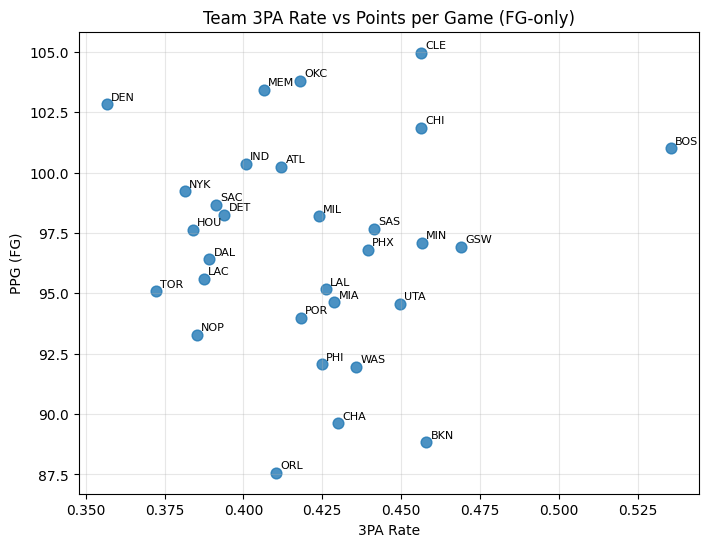

In [13]:

need = {'team_name','shotValue','shot_made_flag','espn_game_id','fg_points'}
if need.issubset(shots.columns):
    tg = (shots.groupby(['team_name','espn_game_id'])
                .agg(fga=('shot_made_flag','size'),
                     three_att=('shotValue', lambda x: np.sum(x==3)),
                     fg_points=('fg_points','sum'))
                .reset_index())
    tg['three_rate'] = tg['three_att'] / tg['fga']
    team_ppg = tg.groupby('team_name').agg(ppg=('fg_points','mean'),
                                           three_rate=('three_rate','mean')).reset_index()

    fig = plt.figure(figsize=(8,6))
    plt.scatter(team_ppg['three_rate'], team_ppg['ppg'], s=60, alpha=0.8)
    for _, r in team_ppg.iterrows():
        plt.annotate(r['team_name'], (r['three_rate'], r['ppg']), xytext=(3,3), textcoords='offset points', fontsize=8)
    plt.title("Team 3PA Rate vs Points per Game (FG‑only)")
    plt.xlabel("3PA Rate"); plt.ylabel("PPG (FG)"); plt.grid(True, alpha=0.3); plt.show()
else:
    print("Need team_name, shotValue, shot_made_flag, espn_game_id, fg_points.")


## 12) Top 10 Points per Game Players (FG‑only)

                   name        ppg  games
152  Gilgeous-Alexander  24.776316     76
213               Jokić  24.428571     70
10        Antetokounmpo  23.880597     67
438              Wagner  23.203125     64
113              Dončić  21.980000     50
407               Tatum  21.861111     72
123              Durant  21.677419     62
97           Cunningham  21.671429     70
268               Maxey  21.442308     52
451          Wembanyama  20.826087     46


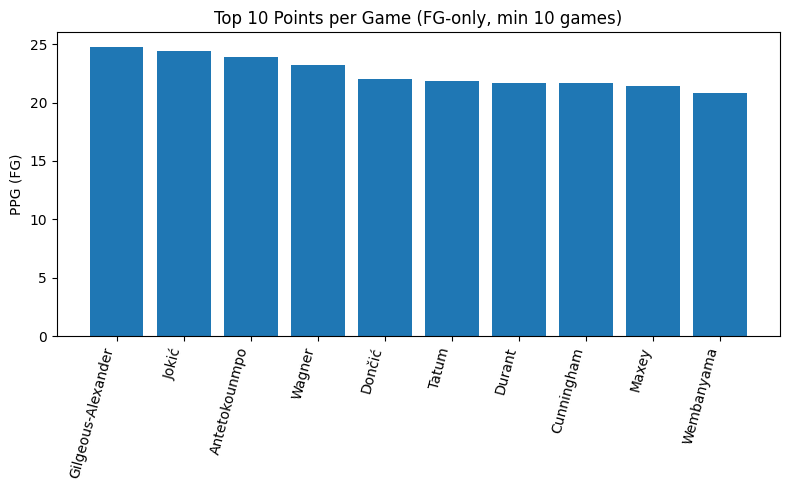

In [14]:

need = {'name','espn_game_id','fg_points'}
if need.issubset(shots.columns):
    pg = (shots.groupby(['name','espn_game_id'])
                .agg(points=('fg_points','sum')).reset_index())
    ppg = (pg.groupby('name')
             .agg(ppg=('points','mean'), games=('espn_game_id','nunique'))
             .reset_index()
             .query('games >= 10')
             .sort_values('ppg', ascending=False)
             .head(10))
    print(ppg)
    fig = plt.figure(figsize=(8,5))
    plt.bar(ppg['name'], ppg['ppg'])
    plt.title("Top 10 Points per Game (FG‑only, min 10 games)")
    plt.ylabel("PPG (FG)"); plt.xticks(rotation=75, ha='right'); plt.tight_layout(); plt.show()
else:
    print("Need name, espn_game_id, fg_points.")


## 13) Player Scatter — eFG% (x) vs Attempts (y), labeled (min 1000 attempts)

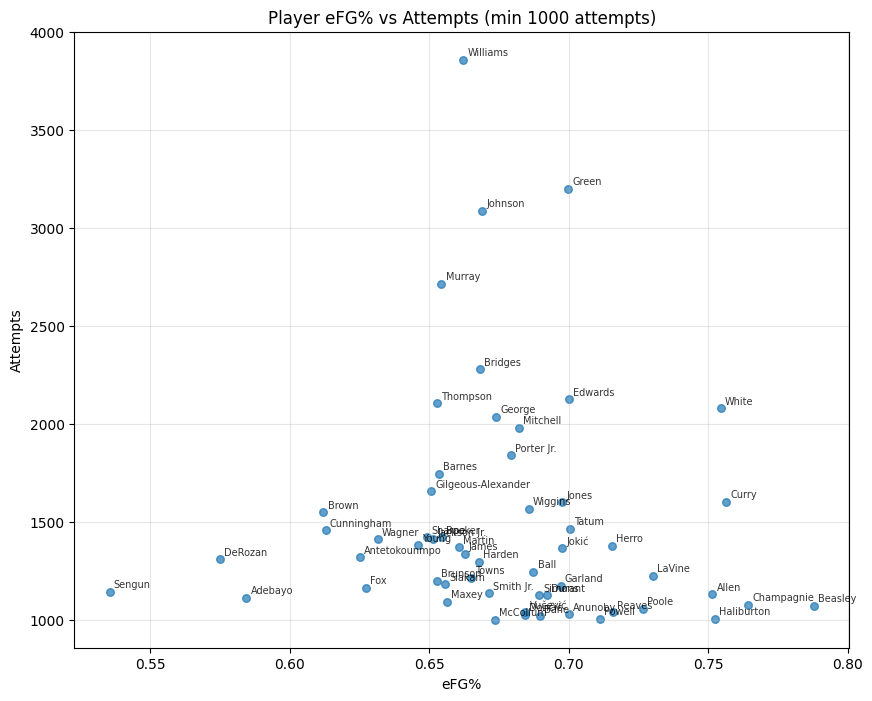

In [15]:

need = {'name','shot_made_flag','shotValue'}
if need.issubset(shots.columns):
    ps = (shots.groupby('name')
                .agg(attempts=('shot_made_flag','size'),
                     makes=('shot_made_flag','sum'),
                     threes=('shotValue', lambda x: (x==3).sum()))
                .reset_index())
    ps['efg_pct'] = (ps['makes'] + 0.5*ps['threes']) / ps['attempts']
    ps = ps.query('attempts >= 1000')

    fig = plt.figure(figsize=(10,8))
    plt.scatter(ps['efg_pct'], ps['attempts'], s=30, alpha=0.7)
    for _, r in ps.iterrows():
        plt.annotate(r['name'], (r['efg_pct'], r['attempts']), xytext=(3,3), textcoords='offset points', fontsize=7, alpha=0.8)
    plt.title("Player eFG% vs Attempts (min 1000 attempts)")
    plt.xlabel("eFG%"); plt.ylabel("Attempts"); plt.grid(True, alpha=0.3); plt.show()
else:
    print("Need name, shot_made_flag, shotValue.")


## 14) Player Bad Shot % (x) vs Attempts (y), labeled (min 800 attempts)

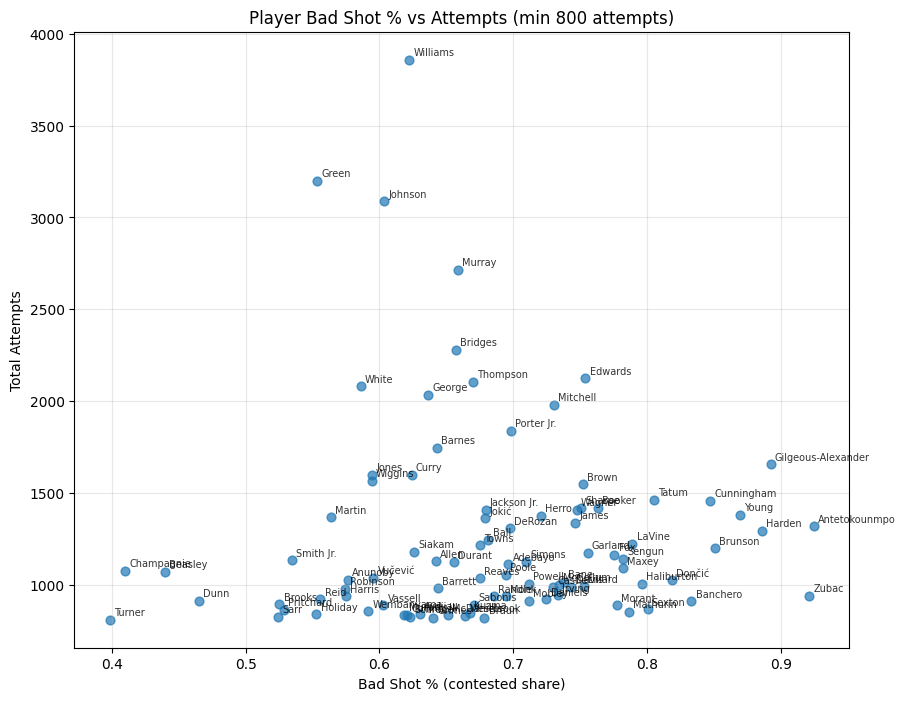

In [16]:

label_words = ('contested', 'heavily', 'tightly')
if 'contest_score' in shots.columns or 'contest_label' in shots.columns:
    s = shots.copy()
    by_score = (s['contest_score'] >= 2) if 'contest_score' in s.columns else pd.Series(False, index=s.index)
    by_label = s['contest_label'].fillna('').str.lower().str.contains('|'.join(label_words)) if 'contest_label' in s.columns else pd.Series(False, index=s.index)
    s['is_contested'] = by_score | by_label

    if {'name','is_contested','shot_made_flag'}.issubset(s.columns):
        bp = (s.groupby('name')
                .agg(attempts=('shot_made_flag','size'),
                     bad_shot_pct=('is_contested','mean'))
                .reset_index())
        bp = bp.query('attempts >= 800')

        fig = plt.figure(figsize=(10,8))
        plt.scatter(bp['bad_shot_pct'], bp['attempts'], s=40, alpha=0.7)
        for _, r in bp.iterrows():
            plt.annotate(r['name'], (r['bad_shot_pct'], r['attempts']), xytext=(3,3), textcoords='offset points', fontsize=7, alpha=0.8)
        plt.title("Player Bad Shot % vs Attempts (min 800 attempts)")
        plt.xlabel("Bad Shot % (contested share)"); plt.ylabel("Total Attempts"); plt.grid(True, alpha=0.3); plt.show()
    else:
        print("Missing columns for per‑player contested calculation; skipping.")
else:
    print("No 'contest_score' or 'contest_label'; skipping bad shot % analysis.")
